# Scratch 3 — Leak-Free CIT Prediction Baseline

ตรวจสอบว่า:
- ไม่มี target leakage ใน feature matrix (E113A’s cold-side outlet = `1TI116.pv` = CIT,
  เลยต้องตัด `E113A_dT_cold` / `E113A_eps` ออก ใช้แค่ cold-inlet กับ hot-side ของ E113A)
- chronological 80/20 split (ไม่ shuffle เพราะเป็น time-series)
- เปรียบเทียบ baseline 5 ตัว: Ridge / RF / XGBoost / AdaBoost / Bagging
  (LSTM ใช้ใน notebook หลัก `5_HX_fouling_CIT_ranking.ipynb`)
- ดู feature importance ระดับ tag ก่อน aggregate per HX

## Setup

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.getcwd())   # so `from hx_config import HX_CONFIG` works
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from hx_config import HX_CONFIG
print(f'{len(HX_CONFIG)} heat exchangers configured')

16 heat exchangers configured


In [2]:
df = pd.read_csv(r'C:\Desktop\Bangchak Internship 2026\Data\Process_information_cleaned.csv',
                 index_col='Timestamp', parse_dates=True)
print('data shape:', df.shape)
print('date range:', df.index.min().date(), '->', df.index.max().date())
df.head(3)

data shape: (836, 96)
date range: 2024-01-01 -> 2026-06-02


,00FIC001.pv,00FC501.pv,1AI001.pv,1FC020.pv,1FC021.pv,1FC022.pv,1FC023.pv,1FC035.pv,1FC062.pv,1FI007.pv,...,1TI195.pv,1TI204.pv,1TI211.pv,1TI212.pv,1TI213.pv,1TI225.pv,439FI003.pv,4TI107.pv,4TI115.pv,1fi005.pv
Timestamp,,,,,,,,,,,,,,,,,,,,,
2024-01-01,94.375190,16.999795,1.368275,124.089211,125.962866,125.978625,124.802684,152.314679,0.0,171.321152,...,218.566940,546.100331,151.058213,206.914077,225.330899,85.847724,160.887027,173.001795,185.483304,528.391371
2024-01-02,92.374818,19.953469,1.399654,125.061664,125.352829,125.308419,125.214303,153.472408,0.0,171.194656,...,221.105864,550.839677,151.924575,208.019745,227.095269,85.580113,165.443664,175.752658,187.760991,530.633258
2024-01-03,97.185508,19.541941,1.351021,125.017004,125.024044,124.964214,124.989005,153.883117,0.0,171.241570,...,222.529668,556.754072,152.279872,213.841493,231.224201,86.101482,167.004084,176.971240,189.410400,531.206542


In [3]:
CP_CRUDE   = 2.2
RHO_CRUDE  = 850
TARGET_TAG = '1TI116.pv'    # CIT
CHARGE_TAG = '1fi005.pv'
O2_TAG     = '1AI001.pv'
LEAK_TARGET_HX = 'E113A'    # cold_out IS the target -- handle separately

In [4]:
def classify_side(items):
    flow = t_in = t_out = None
    unclassified = []
    for tag, label, unit in items:
        ll = label.lower()
        if unit == 'M3/HR':
            flow = tag
        elif unit == 'DEGC':
            if 'inlet' in ll:
                t_in = tag
            elif 'outlet' in ll:
                t_out = tag
            else:
                unclassified.append(tag)
    # fallback: e.g. E113A hot side has 'Residue from Distillation' with no
    # explicit inlet/outlet wording -- treat the lone unclassified temp as inlet
    if t_in is None and unclassified:
        t_in = unclassified[0]
    return flow, t_in, t_out

def parse_hx(cfg):
    cold_flow, cold_in, cold_out = classify_side(cfg['cold'])
    hot_flow,  hot_in,  hot_out  = classify_side(cfg['hot'])
    return dict(cold_flow=cold_flow, cold_in=cold_in, cold_out=cold_out,
                hot_flow=hot_flow,   hot_in=hot_in,   hot_out=hot_out)

streams = {hx: parse_hx(cfg) for hx, cfg in HX_CONFIG.items()}
pd.DataFrame(streams).T

,cold_flow,cold_in,cold_out,hot_flow,hot_in,hot_out
E101AB,1FI007.pv,1TI102.pv,1TI101.pv,1FI010.pv,1TI194.pv,1TI103.pv
E101CD,1FI008.pv,1TI102.pv,1TI104.pv,1FI011.pv,1TI194.pv,1TI105.pv
E101EF,1FI009.pv,1TI102.pv,1TI109.pv,1FI012.pv,1TI194.pv,1TI110.pv
E102,None,1TI107.pv,1TI106.pv,1FC055.pv,1TI165.pv,1TI108.pv
E103AB,1FI015.pv,1TI225.pv,1TI136.pv,1FI018.pv,4TI107.pv,1TI137.pv
E104,1FI015.pv,1TI136.pv,1TI112.pv,None,1TI195.pv,4TI115.pv
E105AB,1FI015.pv,1TI112.pv,1TI114.pv,1FC035.pv,1TI195.pv,1TI113.pv
E106AB,1FI016.pv,1TI225.pv,1TI128.pv,1FI019.pv,4TI107.pv,1TI129.pv
E107AB,1FI016.pv,1TI128.pv,1TI130.pv,None,1TI135.pv,1TI131.pv
E108AB,1FI016.pv,1TI130.pv,1TI132.pv,439FI003.pv,1TI127.pv,1TI133.pv


## 1. Build leak-free feature matrix

สำหรับ HX ทุกตัว ยกเว้น E113A: ใช้ `eps`, `dT_cold`, `dT_hot`, `duty_kW` ตามปกติ.
สำหรับ E113A: ใช้แค่ `cold_in` (= `1TI115.pv`, อุณหภูมิก่อนเข้า HX สุดท้าย) และ
`dT_hot` / `duty_kW` ของ residue side — *ไม่* ใส่ `dT_cold` หรือ `eps` เพราะมัน
มี `1TI116.pv` (= CIT) อยู่ในสูตร.

In [5]:
feat = pd.DataFrame(index=df.index)
for hx, s in streams.items():
    leaky = (hx == LEAK_TARGET_HX)
    if not leaky:
        if s['cold_in'] and s['hot_in']:
            denom = (df[s['hot_in']] - df[s['cold_in']]).replace(0, np.nan)
            feat[f'{hx}_eps'] = ((df[s['cold_out']] - df[s['cold_in']]) / denom).clip(-0.5, 1.5)
        if s['cold_in'] and s['cold_out']:
            feat[f'{hx}_dT_cold'] = df[s['cold_out']] - df[s['cold_in']]
        if s['cold_flow'] and s['cold_in'] and s['cold_out']:
            feat[f'{hx}_duty_kW'] = RHO_CRUDE * df[s['cold_flow']] * CP_CRUDE * (df[s['cold_out']] - df[s['cold_in']]) / 3600
        elif s['hot_flow'] and s['hot_in'] and s['hot_out']:
            feat[f'{hx}_duty_kW'] = RHO_CRUDE * df[s['hot_flow']] * CP_CRUDE * (df[s['hot_in']] - df[s['hot_out']]) / 3600
    if s['hot_in'] and s['hot_out']:
        feat[f'{hx}_dT_hot'] = df[s['hot_in']] - df[s['hot_out']]
    if leaky:
        feat[f'{hx}_cold_in'] = df[s['cold_in']]                         # 1TI115.pv -- NOT the target
        if s['hot_flow'] and s['hot_in'] and s['hot_out']:
            feat[f'{hx}_duty_kW'] = RHO_CRUDE * df[s['hot_flow']] * CP_CRUDE * (df[s['hot_in']] - df[s['hot_out']]) / 3600

feat['total_charge'] = df[CHARGE_TAG]
feat['flue_O2']      = df[O2_TAG]

target = df[TARGET_TAG]

assert TARGET_TAG not in feat.columns
assert not [c for c in feat.columns if 'E113A_dT_cold' in c or 'E113A_eps' in c], 'leakage'
print('feature shape:', feat.shape, '-- no leakage cols present')
feat.head(3)

feature shape: (836, 65) -- no leakage cols present


,E101AB_eps,E101AB_dT_cold,E101AB_duty_kW,E101AB_dT_hot,E101CD_eps,E101CD_dT_cold,E101CD_duty_kW,E101CD_dT_hot,E101EF_eps,E101EF_dT_cold,...,E112AB_dT_hot,E112C_eps,E112C_dT_cold,E112C_duty_kW,E112C_dT_hot,E113A_dT_hot,E113A_cold_in,E113A_duty_kW,total_charge,flue_O2
Timestamp,,,,,,,,,,,,,,,,,,,,,
2024-01-01,0.555895,54.166884,4820.409661,19.293908,0.543429,52.952240,3920.876544,17.595389,0.373633,36.407151,...,76.766721,0.588938,68.223785,5798.466250,233.855089,64.817672,209.954849,5416.934195,528.391371,1.368275
2024-01-02,0.555452,54.620299,4857.170896,19.256323,0.543013,53.397138,3787.501115,17.571471,0.373159,36.694539,...,75.071456,0.575556,68.413587,5890.728078,238.467489,61.653646,212.790326,5298.439880,530.633258,1.399654
2024-01-03,0.554842,55.030054,4894.949835,19.300926,0.543036,53.859117,3863.534174,17.632632,0.372646,36.959537,...,75.716543,0.580199,68.934240,5958.348139,238.667667,61.816796,213.587965,5362.566474,531.206542,1.351021


## 2. Chronological 80/20 train/test split

Train: 2024-01-01 -> 2025-12-16  (n=668)
Test:  2025-12-17 -> 2026-06-02  (n=168)


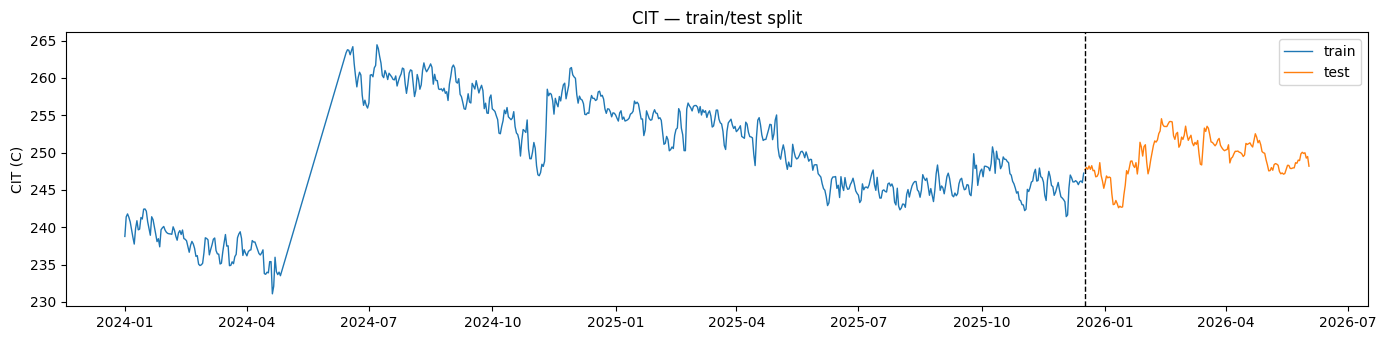

In [6]:
data = feat.copy()
data['CIT'] = target
data = data.dropna()
X = data.drop(columns=['CIT'])
y = data['CIT']

split_idx = int(len(data) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
print(f'Train: {X_train.index.min().date()} -> {X_train.index.max().date()}  (n={len(X_train)})')
print(f'Test:  {X_test.index.min().date()} -> {X_test.index.max().date()}  (n={len(X_test)})')

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.plot(y_train.index, y_train, lw=1, color='tab:blue', label='train')
ax.plot(y_test.index,  y_test,  lw=1, color='tab:orange', label='test')
ax.axvline(X_test.index[0], color='black', ls='--', lw=1)
ax.set_ylabel('CIT (C)'); ax.set_title('CIT — train/test split')
ax.legend(); plt.tight_layout(); plt.show()

## 3. Train 5 baseline models

In [7]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, BaggingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb

models = {
    'Ridge':        Ridge(alpha=1.0),
    'RandomForest': RandomForestRegressor(n_estimators=300, random_state=42),
    'XGBoost':      xgb.XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42),
    'AdaBoost':     AdaBoostRegressor(n_estimators=100, random_state=42),
    'Bagging':      BaggingRegressor(n_estimators=100, random_state=42),
}

results = []
fitted = {}
for name, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    results.append({
        'model': name,
        'R2':   r2_score(y_test, pred),
        'MAE':  mean_absolute_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
        'within_5C_%':  (np.abs(pred - y_test) <= 5).mean()  * 100,
        'within_10C_%': (np.abs(pred - y_test) <= 10).mean() * 100,
    })
    fitted[name] = m

pd.DataFrame(results).sort_values('within_10C_%', ascending=False).reset_index(drop=True)

,model,R2,MAE,RMSE,within_5C_%,within_10C_%
0,AdaBoost,-3.916744,5.197901,5.716072,45.833333,100.000000
1,Bagging,-4.997590,5.793765,6.313167,36.904762,98.214286
2,RandomForest,-5.062864,5.820903,6.347428,36.309524,97.619048
3,Ridge,-5.487049,5.947354,6.565722,27.976190,96.428571
4,XGBoost,-6.271615,6.492712,6.951433,25.000000,96.428571


**หมายเหตุเรื่อง R²:** test window (~20% สุดท้าย) เป็นช่วงเดินเครื่องนิ่งกว่าช่วง train
มาก (CIT std ~2.6°C vs ~7.6°C ใน train) — R² ที่เป็นลบจึงเป็นผลของ variance ที่ test
ต่ำ ไม่ใช่โมเดลพยากรณ์ไม่ได้ ดู `within_10C_%` ตามที่ดีไซน์เดิม
(`CIT_Model_Dashboard_Solution_Design.docx`) ระบุไว้ว่าเกณฑ์รับคือ > 90% within ±5–10°C.

## 4. Random Forest feature importance — top 15 individual features

In [8]:
rf_imp = pd.Series(fitted['RandomForest'].feature_importances_, index=X.columns)\
            .sort_values(ascending=False)
rf_imp.head(15)

E101EF_eps        0.609927
E101CD_eps        0.111364
E101EF_dT_hot     0.081289
E113A_cold_in     0.059546
E109AB_duty_kW    0.027411
E104_eps          0.013680
E108AB_dT_cold    0.006029
E102_eps          0.005546
E111_eps          0.004835
E106AB_dT_cold    0.004710
E108AB_dT_hot     0.004622
E108AB_duty_kW    0.004439
E107AB_eps        0.003946
E103AB_duty_kW    0.003874
E101CD_dT_hot     0.003802
dtype: float64

## 5. Aggregate per HX → HX-level importance to CIT

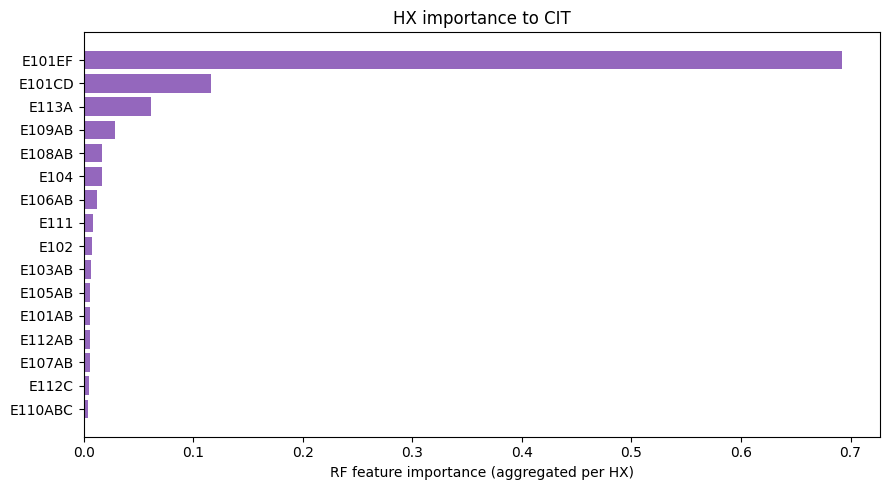

E101EF     0.692280
E101CD     0.116059
E113A      0.061582
E109AB     0.028671
E108AB     0.016796
E104       0.016603
E106AB     0.012349
E111       0.008458
E102       0.007265
E103AB     0.007164
E105AB     0.005730
E101AB     0.005619
E112AB     0.005552
E107AB     0.005401
E112C      0.004552
E110ABC    0.003744
dtype: float64

In [9]:
hx_imp = {}
for hx in HX_CONFIG.keys():
    cols = [c for c in X.columns if c.startswith(hx + '_')]
    if cols:
        hx_imp[hx] = rf_imp[cols].sum()
hx_imp_s = pd.Series(hx_imp).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(hx_imp_s.index, hx_imp_s.values, color='tab:purple')
ax.set_xlabel('RF feature importance (aggregated per HX)')
ax.invert_yaxis(); ax.set_title('HX importance to CIT')
plt.tight_layout(); plt.show()
hx_imp_s